In [1]:
# Deactivate distracting warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
from utils.data_processing import *
from utils.visualization import load_data, plot_event_count, plot_kde, plot_goal_positions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
path = "./idsse-data/DFL-MAT-J03WOH/"
file_name_pos = "DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOH.xml"
file_name_infos = "DFL_02_01_matchinformation_DFL-COM-000002_DFL-MAT-J03WOH.xml"
file_name_events = "DFL_03_02_events_raw_DFL-COM-000002_DFL-MAT-J03WOH.xml"
xy_objects, events, pitch, possession, ballstatus, teamsheets = load_data(path, file_name_pos, file_name_infos, file_name_events)

len(xy_objects["firstHalf"]["Home"][0])=40

In [4]:
def get_first_half_players(valid_counts, positions):
    """
    valid_counts: 각 컬럼별 정상 데이터 개수가 담긴 리스트나 배열 (예: 40개 요소)
    positions: 선수 인덱스를 인덱스로 갖는 포지션 Series (예: 20개 요소)
    """
    starting_players = {}
    
    # 총 선수 명수 계산 (컬럼 수 / 2)
    num_players = len(valid_counts) // 2
    
    for i in range(num_players):
        # 선수의 x좌표 컬럼 인덱스 계산 (0, 2, 4, 6...)
        # y좌표는 2*i + 1이지만, x좌표 하나만 검사해도 출전 여부 파악 가능
        x_col_idx = i * 2 
        
        # 해당 선수의 좌표 데이터가 1개라도 존재한다면(0보다 크다면) 출전한 선수로 간주
        if valid_counts[x_col_idx] > 0:
            # 포지션 Series에서 해당 인덱스(i)의 포지션 값을 가져옴
            pos = positions[i]
            
            # 딕셔너리에 추가
            starting_players[i] = pos
            
    return starting_players

In [5]:
teamsheets['Home']['position']

0      STZ
1     None
2      STZ
3       RV
4      IVR
5      ORM
6      DML
7      DMR
8      IVL
9       ZO
10      ZO
11      TW
12      LV
13     OLM
14    None
15     OLM
16     IVR
17    None
18    None
19     ORM
Name: position, dtype: object

In [6]:
Home_first = xy_objects["firstHalf"]["Home"].xy 
Away_first = xy_objects["firstHalf"]["Away"].xy 
non_nan_counts = np.sum(~np.isnan(Home_first), axis=0)
non_nan_counts_2 = np.sum(~np.isnan(Away_first), axis=0)
print("각 컬럼별 정상(non-NaN) 데이터 개수:")
print(non_nan_counts)
print(non_nan_counts_2)

각 컬럼별 정상(non-NaN) 데이터 개수:
[    0     0     0     0 69424 69424 69424 69424 69424 69424 69424 69424
 69424 69424 69424 69424 69424 69424 69424 69424     0     0 69424 69424
 69424 69424     0     0     0     0 69424 69424     0     0     0     0
     0     0     0     0]
[69424 69424 69424 69424 69424 69424 69424 69424     0     0 69424 69424
 69424 69424     0     0 69424 69424     0     0     0     0 69424 69424
 69424 69424 69424 69424     0     0     0     0 69424 69424     0     0
     0     0]


In [7]:
result_Home = get_first_half_players(non_nan_counts, teamsheets['Home']['position'])
result_Away = get_first_half_players(non_nan_counts_2, teamsheets['Away']['position'])

print("Home 전반전 출전 선수 (인덱스: 포지션):")
for idx, pos in result_Home.items():
    print(f"Index {idx:2d} : {pos}")
print("Away 전반전 출전 선수 (인덱스: 포지션):")
for idx, pos in result_Away.items():
    print(f"Index {idx:2d} : {pos}")

Home 전반전 출전 선수 (인덱스: 포지션):
Index  2 : STZ
Index  3 : RV
Index  4 : IVR
Index  5 : ORM
Index  6 : DML
Index  7 : DMR
Index  8 : IVL
Index  9 : ZO
Index 11 : TW
Index 12 : LV
Index 15 : OLM
Away 전반전 출전 선수 (인덱스: 포지션):
Index  0 : LV
Index  1 : DMR
Index  2 : OLM
Index  3 : IVR
Index  5 : ORM
Index  6 : TW
Index  8 : DML
Index 11 : STZ
Index 12 : RV
Index 13 : ZO
Index 16 : IVL


In [8]:
Home_first_df = pd.DataFrame(Home_first)
Away_first_df = pd.DataFrame(Away_first)

In [9]:
def filter_defenders(result, target_positions = ['LV', 'IVL', 'IVR', 'RV']):
    target_columns = []
    new_column_names = []

    for player_idx, pos in result.items():
        if pos in target_positions:
            # x좌표 컬럼: 인덱스 * 2, y좌표 컬럼: 인덱스 * 2 + 1
            x_col = player_idx * 2
            y_col = player_idx * 2 + 1
            
            target_columns.extend([x_col, y_col])
            new_column_names.extend([f'{pos}_x', f'{pos}_y'])
    return target_columns, new_column_names

In [10]:
target_col_home, new_col_home = filter_defenders(result_Home)
target_col_away, new_col_away = filter_defenders(result_Away)

filtered_df_Home = Home_first_df[target_col_home]
filtered_df_Home.columns = new_col_home

filtered_df_Away = Away_first_df[target_col_away]
filtered_df_Away.columns = new_col_away

print(filtered_df_Home.head())
print(filtered_df_Away.head())

    RV_x   RV_y  IVR_x  IVR_y  IVL_x  IVL_y   LV_x   LV_y
0  12.53  20.32  16.45   6.50  17.32  -5.08  13.81 -14.50
1  12.55  20.34  16.47   6.56  17.29  -5.07  13.82 -14.52
2  12.59  20.35  16.51   6.60  17.27  -5.06  13.84 -14.54
3  12.62  20.38  16.54   6.65  17.25  -5.05  13.85 -14.56
4  12.65  20.41  16.57   6.70  17.22  -5.04  13.87 -14.57
    LV_x   LV_y  IVR_x  IVR_y   RV_x   RV_y  IVL_x  IVL_y
0 -10.31  21.76 -21.51   1.08 -15.58 -14.87 -20.06  11.81
1 -10.27  21.77 -21.49   1.06 -15.57 -14.90 -20.08  11.84
2 -10.22  21.78 -21.47   1.04 -15.56 -14.93 -20.09  11.86
3 -10.19  21.79 -21.45   1.01 -15.55 -14.96 -20.11  11.88
4 -10.13  21.80 -21.42   0.99 -15.54 -15.00 -20.14  11.91


so candiate threshold is 4.5, 4.6, 4.7

In [11]:
thr = 5.8

In [12]:
def classify_morphology(row, x_columns):
    x_values = row[x_columns]
    x_min = x_values.max()
    x_max = x_values.min()
    x_range = abs(x_max - x_min)
    
    if x_range <= 5.8:
        return 'line'
    
    # 3등분
    delta = x_range / 3
    x_low_max = x_min - delta
    x_high_min = x_max + delta
    
    # 각 선수의 영역 분류
    zones = {}
    for col in x_columns:
        x = row[col]
        if x >= x_low_max:
            zones[col] = 'low'
        elif x <= x_high_min:
            zones[col] = 'high'
        else:
            zones[col] = 'middle'
    
    # 영역별 카운트
    zone_counts = {'high': 0, 'middle': 0, 'low': 0}
    for zone in zones.values():
        zone_counts[zone] += 1
    
    # === 패턴 분류 ===
    
    # 1. 3명 low, 1명 high
    if zone_counts['low'] == 3 and zone_counts['high'] == 1:
        if zones['RV_x'] == 'high':
            return 'right_wing_push'
        if zones['IVR_x'] == 'high':
            return 'right_cb_push'
        if zones['IVL_x'] == 'high':
            return 'left_cb_push'
        if zones['LV_x'] == 'high':
            return 'left_wing_push'
    
    # 2. 3명 high, 1명 low
    if zone_counts['high'] == 3 and zone_counts['low'] == 1:
        if zones['RV_x'] == 'low':
            return 'right_wing_drop'
        if zones['IVR_x'] == 'low':
            return 'right_cb_drop'
        if zones['IVL_x'] == 'low':
            return 'left_cb_drop'
        if zones['LV_x'] == 'low':
            return 'left_wing_drop'
    
    # 3. 2명 high, 2명 low (middle 없음)
    if zone_counts['high'] == 2 and zone_counts['low'] == 2 and zone_counts['middle'] == 0:
        # 양 풀백 vs 센터백
        if zones['RV_x'] == 'high' and zones['LV_x'] == 'high':
            return 'wings_push'
        if zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high':
            return 'center_push'
        
        # 좌우 분리
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high':
            return 'right_side_high'
        if zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return 'left_side_high'
        
        # 대각선
        # RV(RB) + IVL(LCB) 둘 다 high
        if zones['RV_x'] == 'high' and zones['IVL_x'] == 'high':
            return 'diagonal_rv_ivl'
        
        # LV(LB) + IVR(RCB) 둘 다 high  ← 이미지의 경우!
        if zones['LV_x'] == 'high' and zones['IVR_x'] == 'high':
            return 'diagonal_lv_ivr'
    
    # 4. Middle - One Up & Two Down -12
    if zone_counts['middle'] == 1:
        if zones['IVL_x'] == 'low' and zones['IVR_x'] == 'low':
            if zones['LV_x'] == 'middle' and zones['RV_x'] == 'high':
                return '1002'
            elif zones['LV_x'] == 'high' and zones['RV_x'] == 'middle':
                return '2001'
        if zones['LV_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['IVR_x'] == 'high' and zones['RV_x'] == 'low':
            return '1020'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0201'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2100'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'low':
            return '0012'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0120'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0210'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'low':
            return '0021'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1200'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2010'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0102'
    #5.Two Up & One Down - 12    
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0221'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2021'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0122'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2102'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return '2201'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0212'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2120'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1022'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2012'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return '2210'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1202'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1220'
    if zone_counts['middle'] == 2:
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0112'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1012'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0211'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1201'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'middle':
            return '1102'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0121'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1210'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2011'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1021'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'middle':
            return '1120'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2101'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2110'
    
    # 6. 기타
    return 'mixed_formation'
 
        

# 적용
x_columns = ['RV_x', 'IVR_x', 'IVL_x', 'LV_x']
filtered_df_Home['morphology'] = filtered_df_Home.apply(
    lambda row: classify_morphology(row, x_columns), axis=1
)


print(filtered_df_Home[['RV_x', 'IVR_x', 'IVL_x', 'LV_x', 'morphology']].head(10))

    RV_x  IVR_x  IVL_x   LV_x morphology
0  12.53  16.45  17.32  13.81       line
1  12.55  16.47  17.29  13.82       line
2  12.59  16.51  17.27  13.84       line
3  12.62  16.54  17.25  13.85       line
4  12.65  16.57  17.22  13.87       line
5  12.70  16.61  17.19  13.89       line
6  12.74  16.65  17.16  13.91       line
7  12.79  16.69  17.14  13.93       line
8  12.83  16.74  17.12  13.95       line
9  12.88  16.78  17.08  13.97       line


morphology
line               18224
wings_push         14787
2001                7742
left_wing_push      5323
1002                3675
1220                3045
right_wing_push     2839
2102                2286
2101                1829
2012                1323
right_cb_drop        828
1012                 782
1102                 705
1202                 497
right_cb_push        448
2010                 407
2100                 377
diagonal_lv_ivr      315
2201                 313
left_side_high       279
0201                 277
2011                 267
diagonal_rv_ivl      265
0102                 257
1022                 249
left_cb_push         249
center_push          197
right_wing_drop      190
2110                 188
0012                 181
1120                 170
0210                 144
2120                 143
1201                 106
0112                  88
0212                  79
2021                  68
2210                  66
left_cb_drop          62
0021          

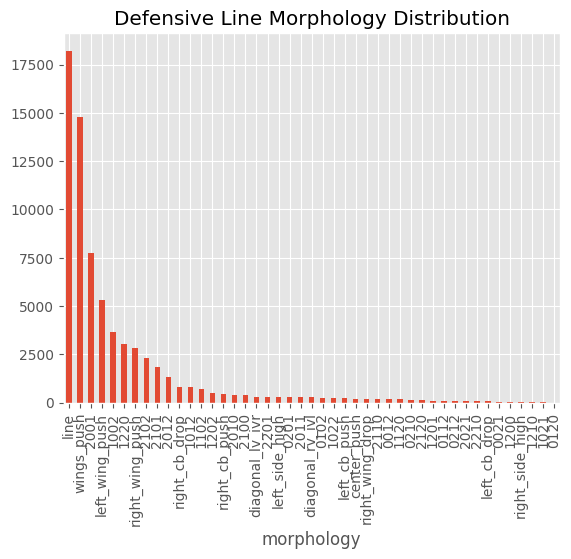

In [13]:
# 형태별 빈도 분석
morphology_counts = filtered_df_Home['morphology'].value_counts()
print(morphology_counts)

# 시간대별 형태 변화
import matplotlib.pyplot as plt
filtered_df_Home['morphology'].value_counts().plot(kind='bar')
plt.title('Defensive Line Morphology Distribution')
plt.show()

In [30]:
import matplotlib.pyplot as plt
import os

def visualize_morphology_samples(df, x_columns, output_dir='morphology_images'):
    """
    각 morphology 유형별로 1개씩 샘플 이미지 생성
    
    Parameters:
    - df: 데이터프레임 (morphology 컬럼 포함)
    - x_columns: ['RV_x', 'IVR_x', 'IVL_x', 'LV_x']
    - output_dir: 이미지 저장 디렉토리
    """
    
    # 출력 디렉토리 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # Y 좌표 컬럼 (X와 매칭되도록)
    y_columns = [col.replace('_x', '_y') for col in x_columns]
    
    # 각 morphology 유형별로 첫 번째 샘플 추출
    morphology_types = df['morphology'].unique()
    
    print(f"총 {len(morphology_types)}개의 morphology 유형 발견")
    print(f"유형: {morphology_types}\n")
    
    for morph_type in morphology_types:
        # 해당 유형의 첫 번째 샘플 가져오기
        sample = df[df['morphology'] == morph_type].iloc[0]
        
        # 좌표 추출
        x_coords = sample[x_columns].values
        y_coords = sample[y_columns].values
    
        
        fig, ax = plt.subplots(figsize=(12, 8))
        pitch.plot(ax=ax)
        
        # 수비 라인 그리기
        ax.plot(x_coords, y_coords, color='red', linestyle='--', 
                linewidth=2.5, zorder=1, label='Defensive Line')
        
        # 선수 위치 표시
        ax.scatter(x_coords, y_coords, color='blue', s=150, 
                   edgecolors='white', linewidth=2, zorder=2)
        
        # 포지션 라벨
        positions = ['RB', 'RCB', 'LCB', 'LB']  # RV, IVR, IVL, LV 순서
        for i in range(4):
            ax.text(x_coords[i], y_coords[i] + 2, positions[i], 
                    color='black', fontsize=12, ha='center', va='center', 
                    fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.8, 
                             edgecolor='black', boxstyle='round,pad=0.3'))
        
        # X 범위 계산 및 표시
        x_range = x_coords.max() - x_coords.min()
        
        # 제목 설정
        title = f"Morphology: {morph_type}\n"
        title += f"X Range: {x_range:.2f}m | Frame: {sample.name}"
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        
        # 범례 추가
        ax.legend(loc='upper right', fontsize=10)
        
        # 저장
        filename = f"{output_dir}/{morph_type}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight', 
                    facecolor='white', edgecolor='none')
        print(f"✅ 저장 완료: {filename}")
        
        plt.close()
    
    print(f"\n🎉 총 {len(morphology_types)}개 이미지 생성 완료!")
    print(f"📁 저장 위치: {output_dir}/")


# 사용 예시
x_columns = ['RV_x', 'IVR_x', 'IVL_x', 'LV_x']
visualize_morphology_samples(filtered_df_Home, x_columns, output_dir='morphology_images')

총 45개의 morphology 유형 발견
유형: ['line' '1002' 'wings_push' 'left_side_high' '2100' 'left_wing_push'
 '2010' '2110' '0210' '1210' '2001' '2012' '1102' '2102' '2101'
 'right_cb_drop' '2201' 'right_wing_push' 'right_cb_push' '0012' '0102'
 '1012' '1202' '2011' '1022' 'right_side_high' '0021' '0120' '1120' '1220'
 'right_wing_drop' '2210' 'diagonal_rv_ivl' '0201' 'left_cb_push' '1201'
 '0112' '1021' 'left_cb_drop' 'diagonal_lv_ivr' '2120' 'center_push'
 '1200' '0212' '2021']

✅ 저장 완료: morphology_images/line.png
✅ 저장 완료: morphology_images/1002.png
✅ 저장 완료: morphology_images/wings_push.png
✅ 저장 완료: morphology_images/left_side_high.png
✅ 저장 완료: morphology_images/2100.png
✅ 저장 완료: morphology_images/left_wing_push.png
✅ 저장 완료: morphology_images/2010.png
✅ 저장 완료: morphology_images/2110.png
✅ 저장 완료: morphology_images/0210.png
✅ 저장 완료: morphology_images/1210.png
✅ 저장 완료: morphology_images/2001.png
✅ 저장 완료: morphology_images/2012.png
✅ 저장 완료: morphology_images/1102.png
✅ 저장 완료: morphology_images/2102.

In [18]:
import pandas as pd

df = Home_first_df.copy()

# 2개 column씩 선수 한 명으로 묶기
player_pairs = [(df.columns[i], df.columns[i+1]) for i in range(0, df.shape[1], 2)]

# 각 선수별 유효 좌표 개수 계산
valid_counts = {}

for idx, (x_col, y_col) in enumerate(player_pairs):
    valid_count = df[[x_col, y_col]].notna().all(axis=1).sum()
    valid_counts[idx] = valid_count

# 유효 frame 수가 많은 상위 11명 선택
top11_player_indices = sorted(valid_counts, key=valid_counts.get, reverse=True)[:11]

# 선택된 11명의 column만 추출
selected_cols = []

for idx in top11_player_indices:
    x_col, y_col = player_pairs[idx]
    selected_cols.extend([x_col, y_col])

Home_first_11_df = df[selected_cols].copy()

print("선택된 선수 index:", top11_player_indices)
print("남은 column 수:", Home_first_11_df.shape[1])
print(Home_first_11_df.head())

선택된 선수 index: [2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 15]
남은 column 수: 22
     4     5      6      7      8     9     10     11    12    13  ...     16  \
0 -0.59  8.72  12.53  20.32  16.45  6.50  0.12  18.05  4.20  7.80  ...  17.32   
1 -0.71  8.63  12.55  20.34  16.47  6.56  0.03  18.03  4.11  7.74  ...  17.29   
2 -0.83  8.54  12.59  20.35  16.51  6.60 -0.06  18.01  4.01  7.68  ...  17.27   
3 -0.97  8.44  12.62  20.38  16.54  6.65 -0.14  17.99  3.91  7.62  ...  17.25   
4 -1.11  8.34  12.65  20.41  16.57  6.70 -0.24  17.97  3.81  7.56  ...  17.22   

     17    18    19     22    23     24     25    30     31  
0 -5.08 -0.99 -8.39  40.36  0.25  13.81 -14.50  1.85 -13.53  
1 -5.07 -1.12 -8.29  40.35  0.25  13.82 -14.52  1.79 -13.52  
2 -5.06 -1.25 -8.20  40.34  0.25  13.84 -14.54  1.71 -13.51  
3 -5.05 -1.40 -8.10  40.33  0.25  13.85 -14.56  1.64 -13.50  
4 -5.04 -1.54 -8.00  40.32  0.25  13.87 -14.57  1.55 -13.50  

[5 rows x 22 columns]


In [19]:
df = Away_first_df.copy()

player_pairs = [(df.columns[i], df.columns[i+1]) for i in range(0, df.shape[1], 2)]

valid_counts = {}

for idx, (x_col, y_col) in enumerate(player_pairs):
    valid_count = df[[x_col, y_col]].notna().all(axis=1).sum()
    valid_counts[idx] = valid_count

top11_away_indices = sorted(valid_counts, key=valid_counts.get, reverse=True)[:11]

selected_cols = []

for idx in top11_away_indices:
    x_col, y_col = player_pairs[idx]
    selected_cols.extend([x_col, y_col])

Away_first_11_df = df[selected_cols].copy()

print("선택된 Away 선수 index:", top11_away_indices)
print("남은 column 수:", Away_first_11_df.shape[1])
print(Away_first_11_df.head())

선택된 Away 선수 index: [0, 1, 2, 3, 5, 6, 8, 11, 12, 13, 16]
남은 column 수: 22
      0      1      2     3     4      5      6     7     10     11  ...  \
0 -10.31  21.76 -10.78 -5.12  1.42  16.90 -21.51  1.08 -1.55 -13.24  ...   
1 -10.27  21.77 -10.78 -5.10  1.55  16.89 -21.49  1.06 -1.52 -13.24  ...   
2 -10.22  21.78 -10.79 -5.09  1.68  16.88 -21.47  1.04 -1.49 -13.22  ...   
3 -10.19  21.79 -10.79 -5.06  1.81  16.87 -21.45  1.01 -1.44 -13.20  ...   
4 -10.13  21.80 -10.80 -5.03  1.94  16.86 -21.42  0.99 -1.40 -13.18  ...   

     16    17    22    23     24     25    26     27     32     33  
0 -7.02  4.81  0.44  0.10 -15.58 -14.87  0.42  25.16 -20.06  11.81  
1 -7.02  4.80  0.48  0.11 -15.57 -14.90  0.52  25.16 -20.08  11.84  
2 -7.00  4.80  0.53  0.12 -15.56 -14.93  0.62  25.16 -20.09  11.86  
3 -7.00  4.80  0.59  0.15 -15.55 -14.96  0.73  25.16 -20.11  11.88  
4 -6.99  4.80  0.65  0.17 -15.54 -15.00  0.85  25.16 -20.14  11.91  

[5 rows x 22 columns]


In [20]:
home_cols = []

for i in range(1, 12):
    home_cols.extend([f"H{i}_x", f"H{i}_y"])

Home_first_11_df.columns = home_cols

In [21]:
away_cols = []

for i in range(1, 12):
    away_cols.extend([f"A{i}_x", f"A{i}_y"])

Away_first_11_df.columns = away_cols

In [22]:
Players_first_df = pd.concat(
    [Home_first_11_df, Away_first_11_df],
    axis=1
)

print(Players_first_df.shape)
print(Players_first_df.head())

(69424, 44)
   H1_x  H1_y   H2_x   H2_y   H3_x  H3_y  H4_x   H4_y  H5_x  H5_y  ...  A7_x  \
0 -0.59  8.72  12.53  20.32  16.45  6.50  0.12  18.05  4.20  7.80  ... -7.02   
1 -0.71  8.63  12.55  20.34  16.47  6.56  0.03  18.03  4.11  7.74  ... -7.02   
2 -0.83  8.54  12.59  20.35  16.51  6.60 -0.06  18.01  4.01  7.68  ... -7.00   
3 -0.97  8.44  12.62  20.38  16.54  6.65 -0.14  17.99  3.91  7.62  ... -7.00   
4 -1.11  8.34  12.65  20.41  16.57  6.70 -0.24  17.97  3.81  7.56  ... -6.99   

   A7_y  A8_x  A8_y   A9_x   A9_y  A10_x  A10_y  A11_x  A11_y  
0  4.81  0.44  0.10 -15.58 -14.87   0.42  25.16 -20.06  11.81  
1  4.80  0.48  0.11 -15.57 -14.90   0.52  25.16 -20.08  11.84  
2  4.80  0.53  0.12 -15.56 -14.93   0.62  25.16 -20.09  11.86  
3  4.80  0.59  0.15 -15.55 -14.96   0.73  25.16 -20.11  11.88  
4  4.80  0.65  0.17 -15.54 -15.00   0.85  25.16 -20.14  11.91  

[5 rows x 44 columns]


In [25]:
Ball_first = xy_objects["firstHalf"]["Ball"].xy 
Ball_first_df = pd.DataFrame(Ball_first)
Ball_first_df.columns = ["ball_x", "ball_y"]

In [28]:
Tracking_first_df = pd.concat(
    [Players_first_df, Ball_first_df],
    axis=1
)

print(Tracking_first_df.shape)

(69424, 46)


In [30]:
Y = filtered_df_Home['morphology']
Tracking_first_df.head()

,H1_x,H1_y,H2_x,H2_y,H3_x,H3_y,H4_x,H4_y,H5_x,H5_y,...,A8_x,A8_y,A9_x,A9_y,A10_x,A10_y,A11_x,A11_y,ball_x,ball_y
0,-0.59,8.72,12.53,20.32,16.45,6.50,0.12,18.05,4.20,7.80,...,0.44,0.10,-15.58,-14.87,0.42,25.16,-20.06,11.81,-5.67,0.11
1,-0.71,8.63,12.55,20.34,16.47,6.56,0.03,18.03,4.11,7.74,...,0.48,0.11,-15.57,-14.90,0.52,25.16,-20.08,11.84,-6.28,0.08
2,-0.83,8.54,12.59,20.35,16.51,6.60,-0.06,18.01,4.01,7.68,...,0.53,0.12,-15.56,-14.93,0.62,25.16,-20.09,11.86,-6.85,0.05
3,-0.97,8.44,12.62,20.38,16.54,6.65,-0.14,17.99,3.91,7.62,...,0.59,0.15,-15.55,-14.96,0.73,25.16,-20.11,11.88,-7.43,0.04
4,-1.11,8.34,12.65,20.41,16.57,6.70,-0.24,17.97,3.81,7.56,...,0.65,0.17,-15.54,-15.00,0.85,25.16,-20.14,11.91,-7.99,0.02


In [31]:
print(Tracking_first_df.shape)
print(Y.shape)
print(Tracking_first_df.index.equals(Y.index))

(69424, 46)
(69424,)
True


In [32]:
dataset_first_df = Tracking_first_df.copy()
dataset_first_df["morphology"] = Y.values

dataset_first_df.head()

,H1_x,H1_y,H2_x,H2_y,H3_x,H3_y,H4_x,H4_y,H5_x,H5_y,...,A8_y,A9_x,A9_y,A10_x,A10_y,A11_x,A11_y,ball_x,ball_y,morphology
0,-0.59,8.72,12.53,20.32,16.45,6.50,0.12,18.05,4.20,7.80,...,0.10,-15.58,-14.87,0.42,25.16,-20.06,11.81,-5.67,0.11,line
1,-0.71,8.63,12.55,20.34,16.47,6.56,0.03,18.03,4.11,7.74,...,0.11,-15.57,-14.90,0.52,25.16,-20.08,11.84,-6.28,0.08,line
2,-0.83,8.54,12.59,20.35,16.51,6.60,-0.06,18.01,4.01,7.68,...,0.12,-15.56,-14.93,0.62,25.16,-20.09,11.86,-6.85,0.05,line
3,-0.97,8.44,12.62,20.38,16.54,6.65,-0.14,17.99,3.91,7.62,...,0.15,-15.55,-14.96,0.73,25.16,-20.11,11.88,-7.43,0.04,line
4,-1.11,8.34,12.65,20.41,16.57,6.70,-0.24,17.97,3.81,7.56,...,0.17,-15.54,-15.00,0.85,25.16,-20.14,11.91,-7.99,0.02,line


In [33]:
print(dataset_first_df.shape)
print(dataset_first_df.isna().sum().sum())
print(dataset_first_df["morphology"].value_counts())

(69424, 47)
0
morphology
line               18224
wings_push         14787
2001                7742
left_wing_push      5323
1002                3675
1220                3045
right_wing_push     2839
2102                2286
2101                1829
2012                1323
right_cb_drop        828
1012                 782
1102                 705
1202                 497
right_cb_push        448
2010                 407
2100                 377
diagonal_lv_ivr      315
2201                 313
left_side_high       279
0201                 277
2011                 267
diagonal_rv_ivl      265
0102                 257
1022                 249
left_cb_push         249
center_push          197
right_wing_drop      190
2110                 188
0012                 181
1120                 170
0210                 144
2120                 143
1201                 106
0112                  88
0212                  79
2021                  68
2210                  66
left_cb_drop          62


In [34]:
# CSV 저장
dataset_first_df.to_csv("tracking_first_with_morphology.csv", index=False)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dataset_first_df["morphology_id"] = le.fit_transform(dataset_first_df["morphology"])

print(le.classes_)
print(dataset_first_df["morphology_id"].value_counts().sort_index())
# label_name = le.inverse_transform([pred_id])

['0012' '0021' '0102' '0112' '0120' '0201' '0210' '0212' '1002' '1012'
 '1021' '1022' '1102' '1120' '1200' '1201' '1202' '1210' '1220' '2001'
 '2010' '2011' '2012' '2021' '2100' '2101' '2102' '2110' '2120' '2201'
 '2210' 'center_push' 'diagonal_lv_ivr' 'diagonal_rv_ivl' 'left_cb_drop'
 'left_cb_push' 'left_side_high' 'left_wing_push' 'line' 'right_cb_drop'
 'right_cb_push' 'right_side_high' 'right_wing_drop' 'right_wing_push'
 'wings_push']
morphology_id
0       181
1        48
2       257
3        88
4         5
5       277
6       144
7        79
8      3675
9       782
10        9
11      249
12      705
13      170
14       36
15      106
16      497
17       20
18     3045
19     7742
20      407
21      267
22     1323
23       68
24      377
25     1829
26     2286
27      188
28      143
29      313
30       66
31      197
32      315
33      265
34       62
35      249
36      279
37     5323
38    18224
39      828
40      448
41       36
42      190
43     2839
44    14787
N

In [ ]:
# 75 frame per sequences
SEQ_LEN = 75
STRIDE = 5

feature_cols = [
    col for col in dataset_first_df.columns
    if col not in ["morphology", "morphology_id"]
]

X_list = []
y_list = []

for start in range(0, len(dataset_first_df) - SEQ_LEN + 1, STRIDE):
    end = start + SEQ_LEN

    X_seq = dataset_first_df.iloc[start:end][feature_cols].values
    y_seq = dataset_first_df.iloc[start:end]["morphology_id"].values

    X_list.append(X_seq)
    y_list.append(y_seq)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int64)

print(X.shape)
print(y.shape)

(13870, 75, 46)
(13870, 75)


In [37]:

print("X shape:", X.shape)
print("y shape:", y.shape)
print("num classes:", len(np.unique(y)))
print("classes:", np.unique(y))

X shape: (13870, 75, 46)
y shape: (13870, 75)
num classes: 45
classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]


In [38]:
num_samples = len(X)

train_end = int(num_samples * 0.7)
val_end = int(num_samples * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (9709, 75, 46) (9709, 75)
Val: (2080, 75, 46) (2080, 75)
Test: (2081, 75, 46) (2081, 75)


In [40]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
class MorphologySequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [41]:
batch_size = 64

train_dataset = MorphologySequenceDataset(X_train, y_train)
val_dataset = MorphologySequenceDataset(X_val, y_val)
test_dataset = MorphologySequenceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [42]:
class LSTMMorphologyModel(nn.Module):
    def __init__(self, input_dim=46, hidden_dim=128, num_layers=2, num_classes=45, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: [batch, seq_len, input_dim]
        out, _ = self.lstm(x)
        # out: [batch, seq_len, hidden_dim]

        logits = self.classifier(out)
        # logits: [batch, seq_len, num_classes]

        return logits

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMMorphologyModel(
    input_dim=46,
    hidden_dim=128,
    num_layers=2,
    num_classes=45,
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(device)

cuda


In [61]:
classes, counts = np.unique(y, return_counts=True)

class_count_df = pd.DataFrame({
    "class_id": classes,
    "count": counts
}).sort_values("count", ascending=False)

print(class_count_df)

    class_id   count
38        38  272250
44        44  221805
19        19  116130
37        37   79845
8          8   55125
18        18   45675
43        43   42585
26        26   34290
25        25   27435
22        22   19845
39        39   12420
9          9   11730
12        12   10575
16        16    7455
40        40    6720
20        20    6105
24        24    5655
32        32    4725
29        29    4695
36        36    4185
5          5    4155
21        21    4005
33        33    3975
2          2    3855
35        35    3735
11        11    3735
31        31    2955
42        42    2850
27        27    2820
0          0    2715
13        13    2550
6          6    2160
28        28    2145
15        15    1590
3          3    1320
7          7    1185
23        23    1020
30        30     990
34        34     930
1          1     720
14        14     540
41        41     540
17        17     300
10        10     135
4          4      75


In [62]:
num_classes = 45
classes, counts = np.unique(y_train, return_counts=True)

class_counts = np.zeros(num_classes, dtype=np.float32)
class_counts[classes] = counts

weights = np.sqrt(class_counts.sum() / (num_classes * class_counts))
weights = np.clip(weights, 0.5, 10.0)

# 핵심: numpy -> torch tensor로 변환
weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [63]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_correct = 0
    total_count = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        # logits: [batch, 75, 45]
        # y_batch: [batch, 75]

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            y_batch.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        preds = logits.argmax(dim=-1)
        total_correct += (preds == y_batch).sum().item()
        total_count += y_batch.numel()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_count

    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                y_batch.reshape(-1)
            )

            total_loss += loss.item() * X_batch.size(0)

            preds = logits.argmax(dim=-1)
            total_correct += (preds == y_batch).sum().item()
            total_count += y_batch.numel()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_count

    return avg_loss, accuracy

In [64]:
num_epochs = 20

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    print(
        f"Epoch [{epoch:02d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch [01/20] Train Loss: 2.1349 | Train Acc: 0.5463 Val Loss: 2.9108 | Val Acc: 0.4213
Epoch [02/20] Train Loss: 1.3655 | Train Acc: 0.6635 Val Loss: 3.2958 | Val Acc: 0.3840
Epoch [03/20] Train Loss: 1.0776 | Train Acc: 0.7123 Val Loss: 3.3384 | Val Acc: 0.4155
Epoch [04/20] Train Loss: 0.8863 | Train Acc: 0.7558 Val Loss: 3.3064 | Val Acc: 0.4365
Epoch [05/20] Train Loss: 0.7397 | Train Acc: 0.7972 Val Loss: 3.7022 | Val Acc: 0.4143
Epoch [06/20] Train Loss: 0.6710 | Train Acc: 0.8186 Val Loss: 3.4708 | Val Acc: 0.3793
Epoch [07/20] Train Loss: 0.6050 | Train Acc: 0.8332 Val Loss: 3.6341 | Val Acc: 0.4137
Epoch [08/20] Train Loss: 0.5444 | Train Acc: 0.8470 Val Loss: 3.6562 | Val Acc: 0.4197
Epoch [09/20] Train Loss: 0.5563 | Train Acc: 0.8405 Val Loss: 3.8886 | Val Acc: 0.4228
Epoch [10/20] Train Loss: 0.4392 | Train Acc: 0.8763 Val Loss: 4.0408 | Val Acc: 0.3979
Epoch [11/20] Train Loss: 0.4134 | Train Acc: 0.8797 Val Loss: 3.8854 | Val Acc: 0.4283
Epoch [12/20] Train Loss: 0.3942

In [57]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 3.5921
Test Accuracy: 0.5391


In [58]:
model.eval()

X_batch, y_batch = next(iter(test_loader))
X_batch = X_batch.to(device)

with torch.no_grad():
    logits = model(X_batch)
    preds = logits.argmax(dim=-1)

print("Input shape:", X_batch.shape)
print("Logits shape:", logits.shape)
print("Pred shape:", preds.shape)
print("Target shape:", y_batch.shape)

Input shape: torch.Size([64, 75, 46])
Logits shape: torch.Size([64, 75, 45])
Pred shape: torch.Size([64, 75])
Target shape: torch.Size([64, 75])


In [65]:

def class_dist(y_split, name):
    classes, counts = np.unique(y_split, return_counts=True)
    df = pd.DataFrame({
        "class_id": classes,
        "count": counts,
        "ratio": counts / counts.sum()
    }).sort_values("count", ascending=False)
    
    print(name)
    print("num classes:", len(classes))
    display(df.head(15))
    return set(classes)

train_classes = class_dist(y_train, "train")
val_classes = class_dist(y_val, "val")
test_classes = class_dist(y_test, "test")

print("Val classes not in train:", sorted(val_classes - train_classes))
print("Test classes not in train:", sorted(test_classes - train_classes))

train
num classes: 41


,class_id,count,ratio
34,38,181770,0.249624
40,44,167475,0.229993
17,19,75855,0.104171
33,37,57810,0.079390
7,8,45075,0.061901
39,43,33570,0.046102
16,18,24570,0.033742
23,26,23910,0.032836
22,25,22965,0.031538
20,22,18225,0.025028


val
num classes: 30


,class_id,count,ratio
26,38,58920,0.377692
29,44,27744,0.177846
10,19,14209,0.091083
25,37,9315,0.059712
17,26,6990,0.044808
27,39,5175,0.033173
16,25,4367,0.027994
24,36,3045,0.019519
28,43,3030,0.019423
5,8,2970,0.019038


test
num classes: 27


,class_id,count,ratio
22,38,31560,0.202210
26,44,26586,0.170341
8,19,26066,0.167009
7,18,20340,0.130322
21,37,12720,0.081499
2,8,7080,0.045363
25,43,5985,0.038347
12,26,3390,0.021720
17,32,2745,0.017588
16,31,2460,0.015762


Val classes not in train: [np.int64(7), np.int64(14), np.int64(23), np.int64(31)]
Test classes not in train: [np.int64(31)]
